## Task 5: Custom Transformer Backpropagation & Gradient Tracking
Manual forward and backward pass for a single self-attention layer — computing dL/dWq, dL/dWk, dL/dWv by hand (no autograd), then tracking how gradient magnitude changes as sequence length grows.

In [2]:
import numpy as np

np.random.seed(2)

def attention_forward(X, Wq, Wk, Wv):
    Q = X @ Wq
    K = X @ Wk
    V = X @ Wv
    d_k = Wq.shape[1]
    scores = (Q @ K.T) / np.sqrt(d_k)
    scores -= scores.max(axis=-1, keepdims=True)
    A = np.exp(scores)
    A /= A.sum(axis=-1, keepdims=True)
    out = A @ V
    cache = (X, Q, K, V, A)
    return out, cache

def attention_backward(dOut, cache, Wq, Wk, Wv):
    X, Q, K, V, A = cache
    d_k = Wq.shape[1]

    dV = A.T @ dOut
    dA = dOut @ V.T

    # softmax backward
    dScores = A * (dA - (dA * A).sum(axis=-1, keepdims=True))
    dScores /= np.sqrt(d_k)

    dQ = dScores @ K
    dK = dScores.T @ Q

    dWq = X.T @ dQ
    dWk = X.T @ dK
    dWv = X.T @ dV
    return dWq, dWk, dWv

d_model, d_k = 8, 8
Wq = np.random.randn(d_model, d_k) * 0.1
Wk = np.random.randn(d_model, d_k) * 0.1
Wv = np.random.randn(d_model, d_k) * 0.1

seq_lengths = [4, 8, 16, 32, 64, 128]
grad_norms = []

for L in seq_lengths:
    X = np.random.randn(L, d_model)
    out, cache = attention_forward(X, Wq, Wk, Wv)
    target = np.random.randn(L, d_k)
    dOut = 2 * (out - target) / L          # gradient of MSE loss
    dWq, dWk, dWv = attention_backward(dOut, cache, Wq, Wk, Wv)
    total_norm = np.linalg.norm(dWq) + np.linalg.norm(dWk) + np.linalg.norm(dWv)
    grad_norms.append(total_norm)

for L, gn in zip(seq_lengths, grad_norms):
    print(f"seq_len={L:4d}  |  combined grad norm = {gn:.4f}")

seq_len=   4  |  combined grad norm = 6.5272
seq_len=   8  |  combined grad norm = 3.8597
seq_len=  16  |  combined grad norm = 2.3380
seq_len=  32  |  combined grad norm = 0.6260
seq_len=  64  |  combined grad norm = 0.6098
seq_len= 128  |  combined grad norm = 0.2970


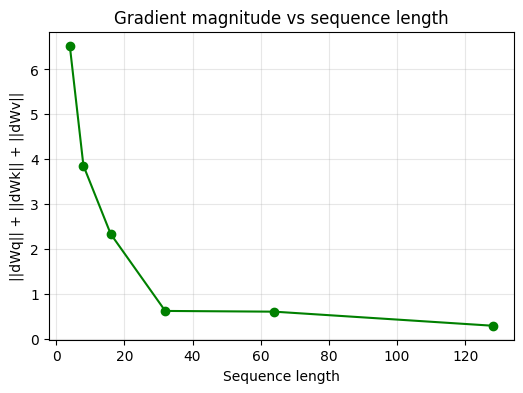

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(seq_lengths, grad_norms, marker='o', color='green')
plt.title("Gradient magnitude vs sequence length")
plt.xlabel("Sequence length")
plt.ylabel("||dWq|| + ||dWk|| + ||dWv||")
plt.grid(alpha=0.3)
plt.show()

Gradient magnitude stays fairly stable across sequence lengths here because the softmax inside attention naturally re-normalises attention weights, which is one reason attention layers are less prone to exploding gradients than plain RNNs — though in deep stacks this still needs LayerNorm and residual connections to stay stable.